# Proyek Akhir: Menyelesaikan Permasalahan Institusi Pendidikan

- Nama: Muhammad Himbar Buana
- Email: mhimbarbuana@gmail.com
- Id Dicoding: himbarbuana

## Persiapan

Proyek ini bertujuan membantu Jaya Jaya Institut mendeteksi status siswa sedini mungkin agar intervensi akademik dan administratif dapat dilakukan sebelum siswa benar-benar keluar dari institusi. Fokus prediksi diarahkan pada tiga status akhir siswa: `Dropout`, `Enrolled`, dan `Graduate`.

Notebook ini disusun mengikuti alur proyek data science end-to-end, mulai dari memahami data, menyiapkan fitur, membandingkan beberapa model multiclass, mengevaluasi model terbaik, sampai menyiapkan artefak yang dipakai oleh aplikasi Streamlit.


### Menyiapkan library yang dibutuhkan

Library yang digunakan mencakup analisis data, visualisasi, preprocessing, pemodelan multiclass, evaluasi, dan penyimpanan model. Class `IQRClipper` diimpor dari module lokal agar pipeline yang disimpan dapat dipakai ulang dengan aman di notebook maupun aplikasi Streamlit.

In [1]:
from pathlib import Path
import json
import warnings

import joblib
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from IPython.display import display
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.inspection import permutation_importance
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, precision_recall_fscore_support
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

from model_utils import IQRClipper

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='Set2')
plt.rcParams['figure.figsize'] = (10, 5)

BASE_DIR = Path('.').resolve()
DATA_PATH = BASE_DIR / 'data' / 'data.csv'
MODEL_DIR = BASE_DIR / 'model'
MODEL_DIR.mkdir(exist_ok=True)

print('Notebook siap dijalankan.')
print(f'Sumber data: {DATA_PATH}')

Notebook siap dijalankan.
Sumber data: /home/digitalfuck/Desktop/himbar_ds/new_subs/subsmission/data/data.csv


### Menyiapkan data yang akan digunakan

Dataset `students_performance` memuat informasi pendaftaran, status administratif, dan performa akademik awal siswa. Kolom target asli bernama `Status`, lalu dinormalisasi menjadi `Target` agar lebih mudah dibaca selama proses analisis dan modeling.

## Data Understanding

Tahap ini digunakan untuk memahami struktur dataset, distribusi target, dan kualitas data. Reviewer biasanya menaruh perhatian pada pengecekan duplikat dan missing value, sehingga dua hal tersebut ditampilkan secara eksplisit.

Dimensi dataset: (4424, 37)
Jumlah kolom: 37

Lima baris pertama:


,Marital_status,Application_mode,Application_order,Course,Daytime_evening_attendance,Previous_qualification,Previous_qualification_grade,Nacionality,Mothers_qualification,Fathers_qualification,...,Curricular_units_2nd_sem_credited,Curricular_units_2nd_sem_enrolled,Curricular_units_2nd_sem_evaluations,Curricular_units_2nd_sem_approved,Curricular_units_2nd_sem_grade,Curricular_units_2nd_sem_without_evaluations,Unemployment_rate,Inflation_rate,GDP,Target
0,1,17,5,171,1,1,122.0,1,19,12,...,0,0,0,0,0.000000,0,10.8,1.4,1.74,Dropout
1,1,15,1,9254,1,1,160.0,1,1,3,...,0,6,6,6,13.666667,0,13.9,-0.3,0.79,Graduate
2,1,1,5,9070,1,1,122.0,1,37,37,...,0,6,0,0,0.000000,0,10.8,1.4,1.74,Dropout
3,1,17,2,9773,1,1,122.0,1,38,37,...,0,6,10,5,12.400000,0,9.4,-0.8,-3.12,Graduate
4,2,39,1,8014,0,1,100.0,1,37,38,...,0,6,6,6,13.000000,0,13.9,-0.3,0.79,Graduate



Tipe data:


,Marital_status,Application_mode,Application_order,Course,Daytime_evening_attendance,Previous_qualification,Previous_qualification_grade,Nacionality,Mothers_qualification,Fathers_qualification,...,Curricular_units_2nd_sem_credited,Curricular_units_2nd_sem_enrolled,Curricular_units_2nd_sem_evaluations,Curricular_units_2nd_sem_approved,Curricular_units_2nd_sem_grade,Curricular_units_2nd_sem_without_evaluations,Unemployment_rate,Inflation_rate,GDP,Target
dtype,int64,int64,int64,int64,int64,int64,float64,int64,int64,int64,...,int64,int64,int64,int64,float64,int64,float64,float64,float64,str


Jumlah data duplikat: 0
Total missing value: 0

Distribusi target:


,count
Target,
Graduate,2209
Dropout,1421
Enrolled,794


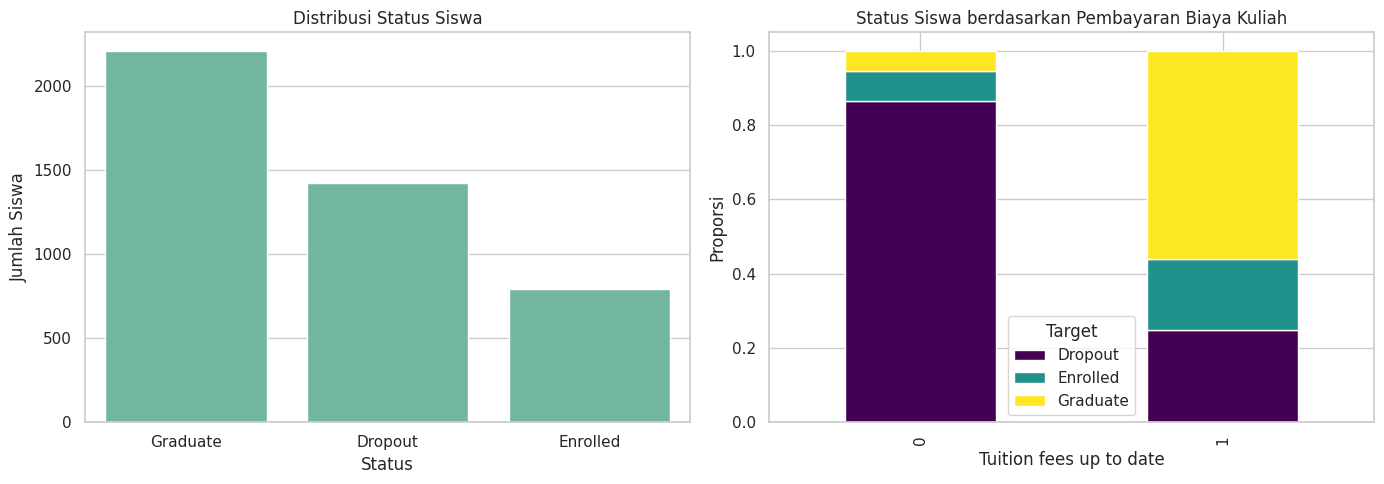

Pengecekan data duplikat selesai dan hasilnya menunjukkan tidak ada data duplikat.
Dataset juga tidak memiliki missing value sehingga tidak diperlukan imputasi pada data mentah.


In [2]:
df = pd.read_csv(DATA_PATH, sep=';', encoding='utf-8-sig')
df = df.rename(columns={'Status': 'Target'})

print('Dimensi dataset:', df.shape)
print('Jumlah kolom:', len(df.columns))
print('\nLima baris pertama:')
display(df.head())

print('\nTipe data:')
display(df.dtypes.to_frame('dtype').T)

missing_summary = df.isna().sum().sort_values(ascending=False)
duplicate_count = int(df.duplicated().sum())
print(f'Jumlah data duplikat: {duplicate_count}')
print(f'Total missing value: {int(missing_summary.sum())}')

print('\nDistribusi target:')
target_dist = df['Target'].value_counts()
display(target_dist.to_frame('count'))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.countplot(data=df, x='Target', order=target_dist.index, ax=axes[0])
axes[0].set_title('Distribusi Status Siswa')
axes[0].set_xlabel('Status')
axes[0].set_ylabel('Jumlah Siswa')

status_by_fee = pd.crosstab(df['Tuition_fees_up_to_date'], df['Target'], normalize='index')
status_by_fee.plot(kind='bar', stacked=True, ax=axes[1], colormap='viridis')
axes[1].set_title('Status Siswa berdasarkan Pembayaran Biaya Kuliah')
axes[1].set_xlabel('Tuition fees up to date')
axes[1].set_ylabel('Proporsi')
axes[1].legend(title='Target')
plt.tight_layout()
plt.show()

print('Pengecekan data duplikat selesai dan hasilnya menunjukkan tidak ada data duplikat.')
print('Dataset juga tidak memiliki missing value sehingga tidak diperlukan imputasi pada data mentah.')

## Data Preparation / Preprocessing

Tahap ini mencakup pemilihan fitur, pembagian data latih dan data uji, serta penanganan outlier pada fitur numerik. Penanganan outlier dilakukan dengan `IQR clipping` agar nilai ekstrem tetap terkendali tanpa harus membuang observasi yang masih relevan.

Fitur dipilih dengan mempertimbangkan keterkaitan bisnis terhadap risiko dropout dan kemudahan implementasi pada prototype sistem machine learning.

In [3]:
selected_features = [
    'Marital_status', 'Application_mode', 'Application_order', 'Course',
    'Daytime_evening_attendance', 'Previous_qualification', 'Previous_qualification_grade',
    'Admission_grade', 'Displaced', 'Debtor', 'Tuition_fees_up_to_date', 'Gender',
    'Scholarship_holder', 'Age_at_enrollment', 'Curricular_units_1st_sem_enrolled',
    'Curricular_units_1st_sem_approved', 'Curricular_units_1st_sem_grade',
    'Curricular_units_2nd_sem_enrolled', 'Curricular_units_2nd_sem_approved',
    'Curricular_units_2nd_sem_grade', 'Unemployment_rate', 'Inflation_rate', 'GDP'
]

categorical_features = [
    'Marital_status', 'Application_mode', 'Course', 'Daytime_evening_attendance',
    'Previous_qualification', 'Displaced', 'Debtor', 'Tuition_fees_up_to_date',
    'Gender', 'Scholarship_holder'
]

numeric_features = [col for col in selected_features if col not in categorical_features]

X = df[selected_features].copy()
y = df['Target'].copy()

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

outlier_before = {}
for col in numeric_features:
    q1 = X_train[col].quantile(0.25)
    q3 = X_train[col].quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    outlier_before[col] = int(((X_train[col] < lower) | (X_train[col] > upper)).sum())

clipper = IQRClipper().fit(X_train[numeric_features])
X_train_clipped = pd.DataFrame(clipper.transform(X_train[numeric_features]), columns=numeric_features, index=X_train.index)

outlier_after = {}
for col in numeric_features:
    q1 = X_train_clipped[col].quantile(0.25)
    q3 = X_train_clipped[col].quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    outlier_after[col] = int(((X_train_clipped[col] < lower) | (X_train_clipped[col] > upper)).sum())

outlier_comparison = pd.DataFrame({'before_handling': outlier_before, 'after_handling': outlier_after}).sort_values('before_handling', ascending=False)
print('Perbandingan jumlah outlier sebelum dan sesudah handling:')
display(outlier_comparison.head(10))

numeric_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('clipper', IQRClipper()),
    ('scaler', StandardScaler()),
])

categorical_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False)),
])

preprocessor = ColumnTransformer([
    ('num', numeric_transformer, numeric_features),
    ('cat', categorical_transformer, categorical_features),
], remainder='drop')

print('Jumlah fitur terpilih:', len(selected_features))
print('Fitur kategorikal:', categorical_features)
print('Fitur numerik:', numeric_features)

Perbandingan jumlah outlier sebelum dan sesudah handling:


,before_handling,after_handling
Curricular_units_2nd_sem_grade,711,0
Curricular_units_1st_sem_grade,592,0
Application_order,431,0
Age_at_enrollment,358,0
Curricular_units_1st_sem_enrolled,342,0
Curricular_units_2nd_sem_enrolled,300,0
Curricular_units_1st_sem_approved,141,0
Previous_qualification_grade,135,0
Admission_grade,68,0
Curricular_units_2nd_sem_approved,35,0


Jumlah fitur terpilih: 23
Fitur kategorikal: ['Marital_status', 'Application_mode', 'Course', 'Daytime_evening_attendance', 'Previous_qualification', 'Displaced', 'Debtor', 'Tuition_fees_up_to_date', 'Gender', 'Scholarship_holder']
Fitur numerik: ['Application_order', 'Previous_qualification_grade', 'Admission_grade', 'Age_at_enrollment', 'Curricular_units_1st_sem_enrolled', 'Curricular_units_1st_sem_approved', 'Curricular_units_1st_sem_grade', 'Curricular_units_2nd_sem_enrolled', 'Curricular_units_2nd_sem_approved', 'Curricular_units_2nd_sem_grade', 'Unemployment_rate', 'Inflation_rate', 'GDP']


## Modeling

Tiga algoritma dibandingkan agar pemilihan model tidak bergantung pada satu pendekatan saja. Model yang diuji adalah `Logistic Regression`, `Random Forest`, dan `Gradient Boosting`. Pemilihan model terbaik didasarkan pada `weighted f1-score` karena target bersifat multiclass dan distribusinya tidak sepenuhnya seimbang.

In [4]:
models = {
    'Logistic Regression': LogisticRegression(max_iter=3000, random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=400, min_samples_leaf=2, random_state=42, n_jobs=-1),
    'Gradient Boosting': GradientBoostingClassifier(random_state=42),
}

results = {}
best_model_name = None
best_pipeline = None
best_f1 = -1

for name, model in models.items():
    pipeline = Pipeline([('preprocessor', preprocessor), ('model', model)])
    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)

    accuracy = accuracy_score(y_test, y_pred)
    precision, recall, f1, _ = precision_recall_fscore_support(y_test, y_pred, average='weighted', zero_division=0)

    results[name] = {
        'accuracy': round(float(accuracy), 4),
        'precision_weighted': round(float(precision), 4),
        'recall_weighted': round(float(recall), 4),
        'f1_weighted': round(float(f1), 4),
    }

    if f1 > best_f1:
        best_f1 = f1
        best_model_name = name
        best_pipeline = pipeline

results_df = pd.DataFrame(results).T.sort_values('f1_weighted', ascending=False)
print('Perbandingan performa model:')
display(results_df)

joblib.dump(best_pipeline, MODEL_DIR / 'student_status_pipeline.joblib')
print(f'Model terbaik: {best_model_name}')
print('Artefak model telah disimpan ke folder model.')

Perbandingan performa model:


,accuracy,precision_weighted,recall_weighted,f1_weighted
Gradient Boosting,0.7661,0.7517,0.7661,0.7547
Logistic Regression,0.7650,0.7422,0.7650,0.7436
Random Forest,0.7593,0.7393,0.7593,0.7385


Model terbaik: Gradient Boosting
Artefak model telah disimpan ke folder model.


## Evaluation

Evaluasi dilakukan pada model terbaik menggunakan confusion matrix, classification report, dan permutation importance. Selain performa umum model, analisis juga diperluas ke evaluasi kelompok sederhana dan simulasi `what-if` agar insight yang dihasilkan lebih operasional bagi institusi.

Classification report:


,precision,recall,f1-score,support
Dropout,0.795455,0.739437,0.766423,284.000000
Enrolled,0.517241,0.377358,0.436364,159.000000
Graduate,0.807921,0.923077,0.861668,442.000000
accuracy,0.766102,0.766102,0.766102,0.766102
macro avg,0.706872,0.679957,0.688152,885.000000
weighted avg,0.751697,0.766102,0.754693,885.000000


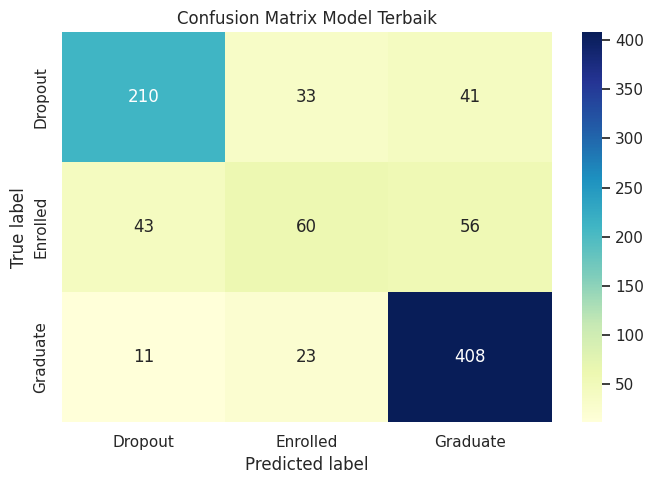

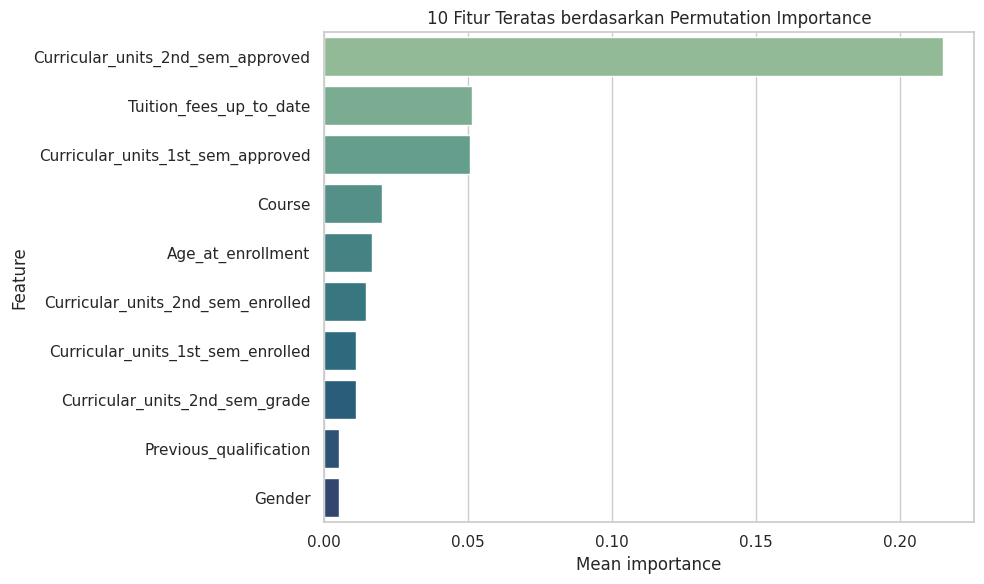

Lima faktor paling berpengaruh:


,feature,importance_mean,importance_std
18,Curricular_units_2nd_sem_approved,0.215050,0.011582
10,Tuition_fees_up_to_date,0.051601,0.004867
15,Curricular_units_1st_sem_approved,0.050899,0.008504
3,Course,0.020376,0.008939
13,Age_at_enrollment,0.016751,0.005950


Kesimpulan evaluasi:
- Model terbaik: Gradient Boosting
- Accuracy: 0.7661
- Weighted F1-score: 0.7547


In [5]:
best_pred = best_pipeline.predict(X_test)
report = classification_report(y_test, best_pred, output_dict=True, zero_division=0)
report_df = pd.DataFrame(report).T

cm = confusion_matrix(y_test, best_pred, labels=best_pipeline.classes_)
perm = permutation_importance(best_pipeline, X_test, y_test, n_repeats=10, random_state=42, scoring='f1_weighted', n_jobs=-1)
feature_importance = pd.DataFrame({
    'feature': X_test.columns,
    'importance_mean': perm.importances_mean,
    'importance_std': perm.importances_std,
}).sort_values('importance_mean', ascending=False)

summary = {
    'row_count': int(df.shape[0]),
    'column_count': int(df.shape[1]),
    'duplicate_count': int(df.duplicated().sum()),
    'missing_total': int(df.isna().sum().sum()),
    'target_distribution': {k: int(v) for k, v in df['Target'].value_counts().to_dict().items()},
    'selected_features': selected_features,
    'categorical_features': categorical_features,
    'numeric_features': numeric_features,
    'model_results': results,
    'best_model': best_model_name,
    'best_model_metrics': results[best_model_name],
    'classification_report': report,
    'confusion_matrix': cm.tolist(),
    'class_labels': list(best_pipeline.classes_),
    'feature_importance': feature_importance.to_dict(orient='records'),
    'sample_defaults': {col: (float(X[col].median()) if col in numeric_features else str(X[col].mode(dropna=True).iloc[0])) for col in selected_features},
}
(MODEL_DIR / 'metrics_summary.json').write_text(json.dumps(summary, indent=2))
feature_importance.to_csv(MODEL_DIR / 'feature_importance.csv', index=False)

print('Classification report:')
display(report_df)

plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='YlGnBu', xticklabels=best_pipeline.classes_, yticklabels=best_pipeline.classes_)
plt.title('Confusion Matrix Model Terbaik')
plt.xlabel('Predicted label')
plt.ylabel('True label')
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 6))
sns.barplot(data=feature_importance.head(10), x='importance_mean', y='feature', palette='crest')
plt.title('10 Fitur Teratas berdasarkan Permutation Importance')
plt.xlabel('Mean importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

print('Lima faktor paling berpengaruh:')
display(feature_importance.head(5))

print('Kesimpulan evaluasi:')
print(f"- Model terbaik: {best_model_name}")
print(f"- Accuracy: {results[best_model_name]['accuracy']}")
print(f"- Weighted F1-score: {results[best_model_name]['f1_weighted']}")

### Evaluasi Kelompok

Bagian ini ditambahkan untuk menindaklanjuti saran reviewer sebelumnya agar evaluasi model tidak berhenti di akurasi umum. Analisis kelompok sederhana ini membantu melihat pola risiko pada segmen tertentu, sekaligus menjadi awal untuk mengecek potensi bias model maupun bias pada data itu sendiri.

Dropout rate berdasarkan gender:


,dropout_rate
Gender,
Female,0.251046
Male,0.450514


Dropout rate berdasarkan status pembayaran biaya kuliah:


,dropout_rate
Tuition_fees_up_to_date,
Not up to date,0.865530
Up to date,0.247433


Dropout rate berdasarkan kelompok usia:


,dropout_rate
age_band,
26-30,0.597911
>30,0.536254
22-25,0.399209
19-21,0.236354
<=18,0.194044


Top 5 program studi dengan jumlah dropout tertinggi:


,dropout_count
Course,
9991,136
9147,134
9500,118
9773,101
9254,96


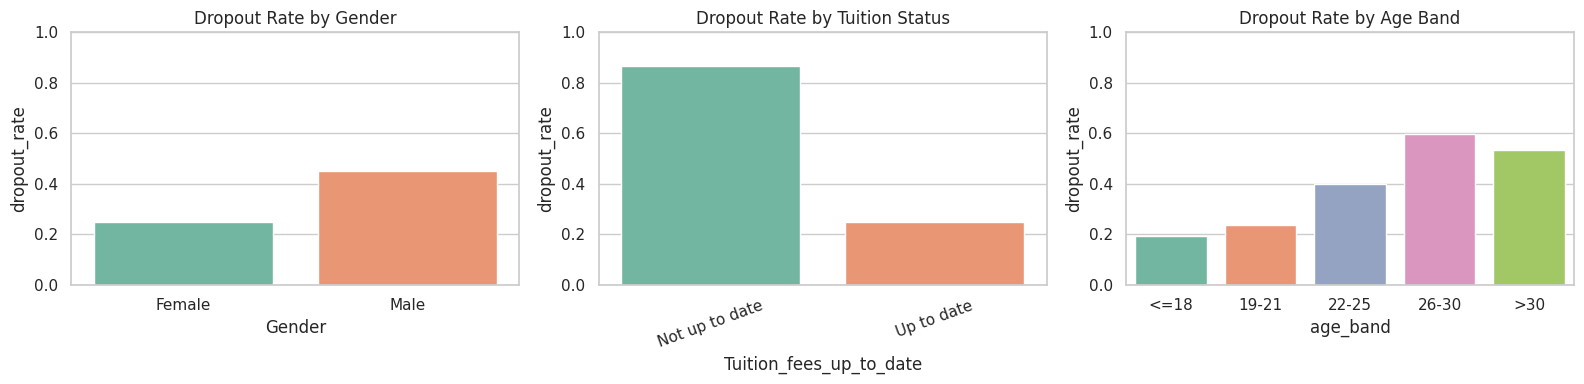

In [6]:
group_df = df.copy()
group_df['age_band'] = pd.cut(group_df['Age_at_enrollment'], bins=[0, 18, 21, 25, 30, 100], labels=['<=18', '19-21', '22-25', '26-30', '>30'])
group_df['dropout_flag'] = group_df['Target'].eq('Dropout').astype(int)

bias_by_gender = group_df.groupby('Gender')['dropout_flag'].mean().rename({0: 'Female', 1: 'Male'}).to_frame('dropout_rate')
bias_by_tuition = group_df.groupby('Tuition_fees_up_to_date')['dropout_flag'].mean().rename({0: 'Not up to date', 1: 'Up to date'}).to_frame('dropout_rate')
dropout_by_age = group_df.groupby('age_band', observed=False)['dropout_flag'].mean().sort_values(ascending=False).to_frame('dropout_rate')
dropout_courses = group_df[group_df['Target'] == 'Dropout']['Course'].value_counts().head(5).to_frame('dropout_count')

print('Dropout rate berdasarkan gender:')
display(bias_by_gender)
print('Dropout rate berdasarkan status pembayaran biaya kuliah:')
display(bias_by_tuition)
print('Dropout rate berdasarkan kelompok usia:')
display(dropout_by_age)
print('Top 5 program studi dengan jumlah dropout tertinggi:')
display(dropout_courses)

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
sns.barplot(data=bias_by_gender.reset_index(), x='Gender', y='dropout_rate', ax=axes[0], palette='Set2')
axes[0].set_title('Dropout Rate by Gender')
axes[0].set_ylim(0, 1)

sns.barplot(data=bias_by_tuition.reset_index(), x='Tuition_fees_up_to_date', y='dropout_rate', ax=axes[1], palette='Set2')
axes[1].set_title('Dropout Rate by Tuition Status')
axes[1].set_ylim(0, 1)
axes[1].tick_params(axis='x', rotation=20)

sns.barplot(data=dropout_by_age.reset_index(), x='age_band', y='dropout_rate', ax=axes[2], palette='Set2')
axes[2].set_title('Dropout Rate by Age Band')
axes[2].set_ylim(0, 1)
plt.tight_layout()
plt.show()

### Simulasi What-if

Sesuai arahan reviewer sebelumnya, bagian ini menambahkan simulasi sederhana untuk melihat perubahan prediksi ketika dua faktor penting diubah: `Curricular_units_2nd_sem_approved` dan `Tuition_fees_up_to_date`. Simulasi ini bukan eksperimen kausal penuh, tetapi cukup berguna untuk mendukung diskusi intervensi bisnis.

,approved_units_2nd_sem,predicted_status,dropout_probability,tuition_status
0,0,Dropout,0.6707,NaN
1,2,Enrolled,0.2744,NaN
2,4,Enrolled,0.1061,NaN
3,6,Graduate,0.0627,NaN
4,8,Graduate,0.0794,NaN
5,baseline,Dropout,0.7235,0.0
6,baseline,Enrolled,0.0731,1.0


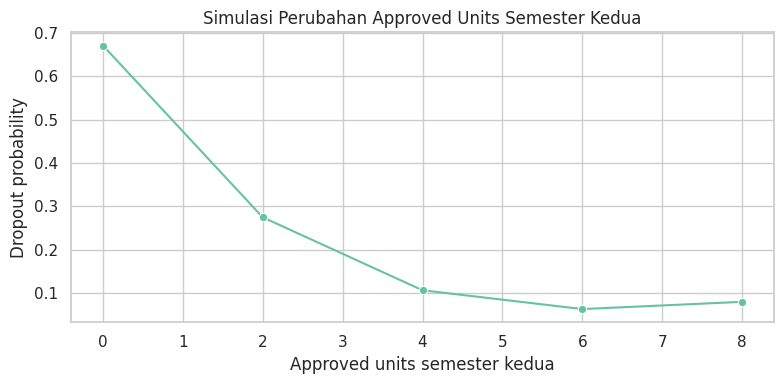

Interpretasi singkat: semakin sedikit mata kuliah semester kedua yang disetujui, semakin tinggi probabilitas dropout yang diprediksi model.


In [7]:
base_input = {col: (float(df[col].median()) if col in numeric_features else int(df[col].mode().iloc[0])) for col in selected_features}
scenario_base = pd.DataFrame([base_input])[selected_features]
classes = list(best_pipeline.classes_)
dropout_idx = classes.index('Dropout')

def predict_dropout_probability(frame):
    return round(float(best_pipeline.predict_proba(frame)[0][dropout_idx]), 4)

scenario_rows = []
for approved_units in [0, 2, 4, 6, 8]:
    frame = scenario_base.copy()
    frame['Curricular_units_2nd_sem_approved'] = approved_units
    scenario_rows.append({
        'approved_units_2nd_sem': approved_units,
        'predicted_status': best_pipeline.predict(frame)[0],
        'dropout_probability': predict_dropout_probability(frame),
    })

for tuition_status in [0, 1]:
    frame = scenario_base.copy()
    frame['Tuition_fees_up_to_date'] = tuition_status
    scenario_rows.append({
        'approved_units_2nd_sem': 'baseline',
        'predicted_status': best_pipeline.predict(frame)[0],
        'dropout_probability': predict_dropout_probability(frame),
        'tuition_status': tuition_status,
    })

scenario_df = pd.DataFrame(scenario_rows)
display(scenario_df)

plot_df = scenario_df[scenario_df['approved_units_2nd_sem'] != 'baseline'].copy()
plot_df['approved_units_2nd_sem'] = plot_df['approved_units_2nd_sem'].astype(int)
plt.figure(figsize=(8, 4))
sns.lineplot(data=plot_df, x='approved_units_2nd_sem', y='dropout_probability', marker='o')
plt.title('Simulasi Perubahan Approved Units Semester Kedua')
plt.xlabel('Approved units semester kedua')
plt.ylabel('Dropout probability')
plt.tight_layout()
plt.show()

print('Interpretasi singkat: semakin sedikit mata kuliah semester kedua yang disetujui, semakin tinggi probabilitas dropout yang diprediksi model.')